In [1]:
# Task 4 - Machine Learning Models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create Student Performance Dataset

data = {
    "Study_Hours": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6,
                    6, 7, 7, 8, 8, 9, 9, 10, 10, 11],

    "Attendance": [60, 65, 68, 70, 72, 75, 78, 80, 82, 84,
                    85, 87, 88, 90, 91, 92, 93, 95, 96, 98],

    "Previous_Marks": [45, 48, 50, 52, 55, 58, 60, 62, 65, 67,
                       68, 70, 72, 75, 77, 80, 82, 85, 87, 90],

    "Final_Marks": [48, 50, 53, 56, 59, 62, 65, 67, 70, 72,
                    74, 76, 78, 81, 83, 85, 87, 90, 92, 95]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
df.head()

Dataset created successfully!


,Study_Hours,Attendance,Previous_Marks,Final_Marks
0,1,60,45,48
1,2,65,48,50
2,2,68,50,53
3,3,70,52,56
4,3,72,55,59


In [3]:
# Inspect the Dataset

print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (20, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     20 non-null     int64
 1   Attendance      20 non-null     int64
 2   Previous_Marks  20 non-null     int64
 3   Final_Marks     20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes

Statistical Summary:


,Study_Hours,Attendance,Previous_Marks,Final_Marks
count,20.000000,20.000000,20.000000,20.000000
mean,6.000000,82.450000,67.400000,72.150000
std,2.991215,11.095163,13.581721,14.379353
min,1.000000,60.000000,45.000000,48.000000
25%,3.750000,74.250000,57.250000,61.250000
50%,6.000000,84.500000,67.500000,73.000000
75%,8.250000,91.250000,77.750000,83.500000
max,11.000000,98.000000,90.000000,95.000000


In [4]:
# Check Missing Values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Study_Hours       0
Attendance        0
Previous_Marks    0
Final_Marks       0
dtype: int64


In [5]:
# Linear Regression

X = df[["Study_Hours", "Attendance", "Previous_Marks"]]
y = df["Final_Marks"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16
Testing samples: 4


In [6]:
# Train Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [7]:
# Make Predictions

y_pred = linear_model.predict(X_test)

print("Actual Marks:")
print(y_test.values)

print("\nPredicted Marks:")
print(y_pred)

Actual Marks:
[48 90 85 50]

Predicted Marks:
[46.21983277 90.17989485 85.31291569 50.61002724]


In [8]:
# Evaluate Linear Regression Model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Evaluation")
print("----------------------------")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Evaluation
----------------------------
MAE: 0.7207512510293306
MSE: 0.9178517425247764
RMSE: 0.9580457935426555
R² Score: 0.9975470806947726


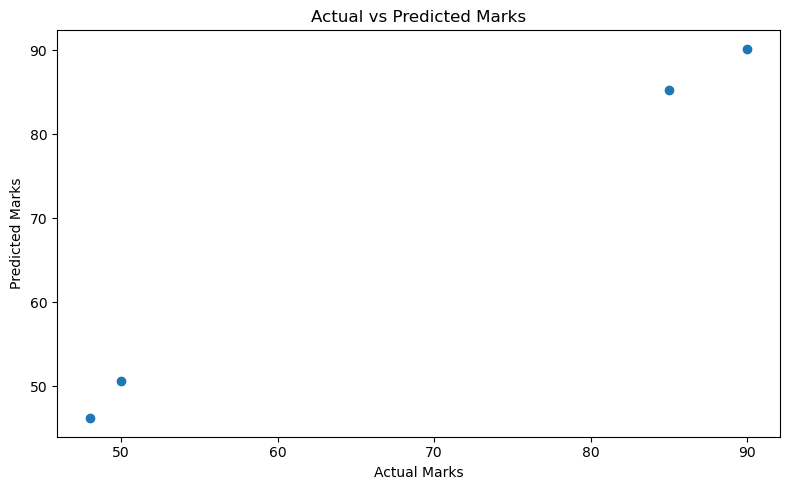

In [9]:
# Actual vs Predicted Marks

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")

plt.tight_layout()
plt.show()

In [10]:
# Create Pass/Fail Target

df["Pass"] = (df["Final_Marks"] >= 60).astype(int)

print(df[["Final_Marks", "Pass"]])

    Final_Marks  Pass
0            48     0
1            50     0
2            53     0
3            56     0
4            59     0
5            62     1
6            65     1
7            67     1
8            70     1
9            72     1
10           74     1
11           76     1
12           78     1
13           81     1
14           83     1
15           85     1
16           87     1
17           90     1
18           92     1
19           95     1


In [11]:
# Prepare Data for Classification

X = df[["Study_Hours", "Attendance", "Previous_Marks"]]
y = df["Pass"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16
Testing samples: 4


In [12]:
# Train Logistic Regression Model

logistic_model = LogisticRegression()

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [13]:
# Make Classification Predictions

y_pred_class = logistic_model.predict(X_test)

print("Actual Classes:")
print(y_test.values)

print("\nPredicted Classes:")
print(y_pred_class)

Actual Classes:
[1 0 1 1]

Predicted Classes:
[1 0 1 1]


In [14]:
# Classification Accuracy

accuracy = accuracy_score(y_test, y_pred_class)

print("Classification Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Classification Accuracy: 1.0
Accuracy Percentage: 100.0 %


In [15]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_class)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1 0]
 [0 3]]


In [16]:
# Classification Report

print("Classification Report:")
print(classification_report(y_test, y_pred_class))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



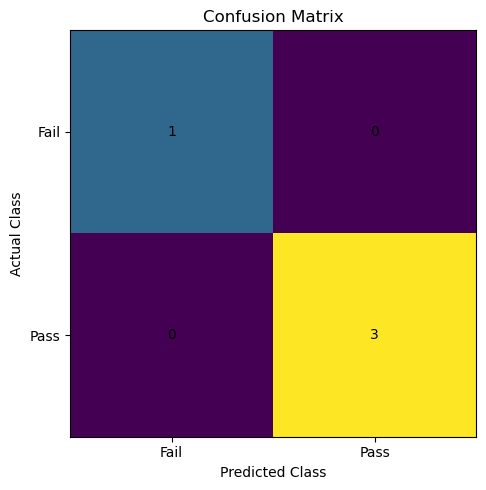

In [17]:
# Confusion Matrix Visualization

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ["Fail", "Pass"])
plt.yticks([0, 1], ["Fail", "Pass"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

# Key Findings

## Dataset Preparation

- A student performance dataset was created using study hours, attendance, previous marks, and final marks.
- The dataset was inspected for missing values.
- No missing values were found.
- The data was divided into training and testing sets.

## Linear Regression

- Linear Regression was used to predict final marks.
- Study hours, attendance, and previous marks were used as input features.
- MAE, MSE, RMSE, and R² Score were used to evaluate the model.
- Actual and predicted marks were visualized using a scatter plot.

## Logistic Regression

- Logistic Regression was used to classify students as Pass or Fail.
- Students scoring 60 or above were classified as Pass.
- Accuracy was calculated to evaluate the classification model.
- A confusion matrix and classification report were generated.

## Conclusion

Two Machine Learning models were successfully implemented using Python and Scikit-learn. Linear Regression was used for predicting numerical values, while Logistic Regression was used for classification. The task demonstrated the complete basic Machine Learning workflow from data preparation and model training to prediction and evaluation.